In [1]:
import h5py 
import scipy 
import numpy as np 
import matplotlib.pyplot as plt 
from scipy.optimize import curve_fit
from scipy import stats
import os
import spts
import spts.camera
from spts.camera import CXDReader

In [2]:
def make_circle_mask(diameter):
    center = (diameter-1.) / 2.
    x,y = np.meshgrid(np.arange(diameter), np.arange(diameter))
    rsq = (x-center)**2 + (y-center)**2
    mask = rsq <= center**2
    return mask

def combine_datafiles(filelist): 
    '''
    input:
    filelist - list of directory and filenames of the analysed and to be combined spts.cxi files
    
    output:
    [0]: hits_correctedall - array with length len(filelist)
    [1]: hitxall - array with length len(found particles)
    [2]: hityall - array with length len(found particles)
    [3]: hits_correctedall_single - array with length len(found particles)
    [4]: hitframeall - array with length len(found particles)
    - opens spts.cxi file
    - ignores hits with intensity < 0
    - NO FURTHER REMOVAL OF PARTICLES DONE HERE
    '''
    
    n_data = len(filelist)
    hits_corrected = []
    hits_correctedall = []
    hits_correctedall_single = []
    hitxall = []
    hityall = []
    hitframeall = []
    
    for i in range(n_data):
            
        f_name = filelist[i]
        print(i+1, '/',n_data, f_name)

        hits = 0  
        frames = 0 
        hit_intensity = 0 
        hit_intensities = np.empty(shape = (0)) 
        hit_x = np.empty(shape = (0)) # array for storing x-location of hit 
        hit_y = np.empty(shape = (0)) # array for storing y-location of hit 
        hit_frame = np.empty(shape = (0), dtype = int) # array for storing frame number of hits 

        f = h5py.File(f_name, 'r')

        frames += f['/5_detect/n'].shape[0] 
        hits += np.sum(f['/5_detect/n'])
        hits_per_frame = np.array(f["/5_detect/n"])

        #print('Number of frames:', frames) 
        #print('Number of raw hits:', hits) 

        for i in range(0, f['/5_detect/x'].shape[0]): # frame counter 
            for j in range(0, f['/5_detect/n'][i]): # particle counter 
                if f['/6_analyse/peak_sum'][i, j] > 0: # ignore hits with intensity lower than zero 
                    hit_x = np.append(hit_x, f['/5_detect/x'][i, j]) 
                    hit_y = np.append(hit_y, f['/5_detect/y'][i, j]) 
                    hit_frame = np.append(hit_frame, i)
                           
        a = np.array(f['/6_analyse/peak_sum']) 
        real_hits = np.sum((a > 0)) 
        #print('Number of real hits (intensity > 0):', real_hits) 
        #print()
        hit_intensities = np.append(hit_intensities, a[a > 0]) 

        sat_pix = np.array(f["/1_raw/saturated_n_pixels"])
        success_pix = np.array(f["/1_raw/success"])

        num_saturated_pixels = np.sum(sat_pix[sat_pix != 0])

        num_saturated_frames = np.sum(success_pix == 0)
        num_nonsaturated_frames = np.sum(success_pix == 1)

        fraction_saturated = num_saturated_frames / num_nonsaturated_frames

        #print("Number of saturated pixels: %s" % (num_saturated_pixels))
        print("Number of saturated frames: %s/%s" % (num_saturated_frames, frames))
        #print("Number of non-saturated frames: %s/%s" % (num_nonsaturated_frames,frames))
        #print("Percentage of saturated frames: %.4s%%" % (fraction_saturated*100))

        av_intensity = np.mean(hit_intensities) 
        med_intensity = np.median(hit_intensities) 
        std_intensity = np.std(hit_intensities) 
        min_intensity = np.min(hit_intensities) 
        max_intensity = np.max(hit_intensities) 
        mad_intensity = scipy.stats.median_abs_deviation(hit_intensities)

        hits_corrected, hitx, hity, hitframe = [], [], [], []
        hits_remain, hits_del = 0, 0
        for h in range(len(hit_intensities)): 
            hit_h = hit_intensities[h] 
            hx, hy, hf = hit_x[h], hit_y[h], hit_frame[h]
            if hit_h >= 0 : 
                hitx.append(hx) 
                hity.append(hy) 
                hitframe.append(hf)
                hits_corrected.append(hit_h) 
                hits_remain += 1
            else:
                hits_del += 1

        hits_corrected = np.array(hits_corrected)
        hitx = np.array(hitx) 
        hity = np.array(hity) 
        hitframe = np.array(hitframe)
            
        hits_correctedall = np.append(hits_correctedall, np.median(hits_corrected**(1/6))) # appends median sixths root intensity
        hits_correctedall_single = np.append(hits_correctedall_single, hits_corrected**(1/6)) # appends all sixths root hit intensities
        hitxall = np.append(hitxall, hitx) # all hit x-positions
        hityall = np.append(hityall, hity) # all hit y-positions
        hitframeall = np.append(hitframeall, hitframe) # all hit frame numbers
        
    return hits_correctedall, hitxall, hityall, hits_correctedall_single, hitframeall

def Gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))

def plot_DMA(filename, datanumber):
    with open(filename, "rb") as f:
        list1 = []
        for line in f:
            list1 = np.append(list1, line)
            #print(line)

    #load all lines including actual data into list2. Neglecting all supporting 
    #        information from the txt file. 
    list2 = []
    for i in range(21, np.shape(list1)[0]-27):   
        list2 = np.append(list2, list1[i].astype(str))

    #generating a 2D array from list2
    arr=list2
    sample = np.zeros((len(arr),len(arr[0].split("\t")) ))
    for i in range(len(arr)):
        #print(arr[i])
        sample[i] = arr[i].split("\t")

    diameter = sample[:,0]
    s = datanumber
    
    return diameter, sample[:,s]

def linear(x, a):
    return a*x

def linear_b(x, a, b):
    return a*x + b

In [3]:
#20 nm data: 
a_list = ['/home/tejvarmay/scattering_data/data/newdata/data00431_analysis_d15/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00432_analysis_d15/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00433_analysis_d15/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00434_analysis_d15/spts.cxi',
         
        '/home/tejvarmay/scattering_data/data/newdata/data00435_analysis_d15/spts.cxi']

a_list2 = ['/home/tejvarmay/scattering_data/data/newdata/data00431_analysis_d5/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00432_analysis_d5/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00433_analysis_d5/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00434_analysis_d5/spts.cxi',
         
        '/home/tejvarmay/scattering_data/data/newdata/data00435_analysis_d5/spts.cxi']

#30 nm data: 
b_list = ['/home/tejvarmay/scattering_data/data/newdata/data00415_analysis_d15/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00416_analysis_d15/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00417_analysis_d15/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00418_analysis_d15/spts.cxi',
         
        '/home/tejvarmay/scattering_data/data/newdata/data00419_analysis_d15/spts.cxi']

b_list2 = ['/home/tejvarmay/scattering_data/data/newdata/data00415_analysis_d5/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00416_analysis_d5/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00417_analysis_d5/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00418_analysis_d5/spts.cxi',
         
        '/home/tejvarmay/scattering_data/data/newdata/data00419_analysis_d5/spts.cxi']

#40 nm data: 
c_list = ['/home/tejvarmay/scattering_data/data/newdata/data00408_analysis_d15/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00409_analysis_d15/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00410_analysis_d15/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00411_analysis_d15/spts.cxi',
         
        '/home/tejvarmay/scattering_data/data/newdata/data00412_analysis_d15/spts.cxi']


c_list2 = ['/home/tejvarmay/scattering_data/data/newdata/data00408_analysis_d5/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00409_analysis_d5/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00410_analysis_d5/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00411_analysis_d5/spts.cxi',
         
        '/home/tejvarmay/scattering_data/data/newdata/data00412_analysis_d5/spts.cxi']

#50 nm data: 
d_list =['/home/tejvarmay/scattering_data/data/newdata/data00395_analysis_d15/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00396_analysis_d15/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00397_analysis_d15/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00398_analysis_d15/spts.cxi',
         
        '/home/tejvarmay/scattering_data/data/newdata/data00399_analysis_d15/spts.cxi']



d_list2 =['/home/tejvarmay/scattering_data/data/newdata/data00395_analysis_d5/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00396_analysis_d5/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00397_analysis_d5/spts.cxi',

        '/home/tejvarmay/scattering_data/data/newdata/data00398_analysis_d5/spts.cxi',
         
        '/home/tejvarmay/scattering_data/data/newdata/data00399_analysis_d5/spts.cxi']



In [4]:
#combining and creating a dataset from the spts.cxi data files for each particle size and size window. 
#20 nm:
PS20 = combine_datafiles(a_list)
PS202 = combine_datafiles(a_list2)
#30 nm:
PS30 = combine_datafiles(b_list)
PS302 = combine_datafiles(b_list2)
#40 nm:
PS40 = combine_datafiles(c_list)
PS402 = combine_datafiles(c_list2)
#50 nm:
PS50 = combine_datafiles(d_list)
PS502 = combine_datafiles(d_list2)

print("done. ")

1 / 5 /home/tejvarmay/scattering_data/data/newdata/data00431_analysis_d15/spts.cxi
Number of saturated frames: 2/2000
2 / 5 /home/tejvarmay/scattering_data/data/newdata/data00432_analysis_d15/spts.cxi
Number of saturated frames: 0/2000
3 / 5 /home/tejvarmay/scattering_data/data/newdata/data00433_analysis_d15/spts.cxi
Number of saturated frames: 0/2000
4 / 5 /home/tejvarmay/scattering_data/data/newdata/data00434_analysis_d15/spts.cxi
Number of saturated frames: 0/2000
5 / 5 /home/tejvarmay/scattering_data/data/newdata/data00435_analysis_d15/spts.cxi
Number of saturated frames: 1/2000
1 / 5 /home/tejvarmay/scattering_data/data/newdata/data00431_analysis_d5/spts.cxi
Number of saturated frames: 2/2000
2 / 5 /home/tejvarmay/scattering_data/data/newdata/data00432_analysis_d5/spts.cxi
Number of saturated frames: 0/2000
3 / 5 /home/tejvarmay/scattering_data/data/newdata/data00433_analysis_d5/spts.cxi
Number of saturated frames: 0/2000
4 / 5 /home/tejvarmay/scattering_data/data/newdata/data0043

2705
2738
2705


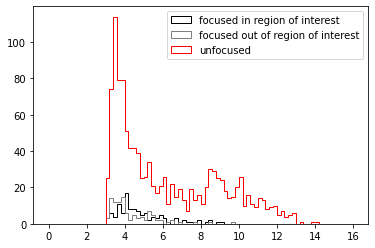

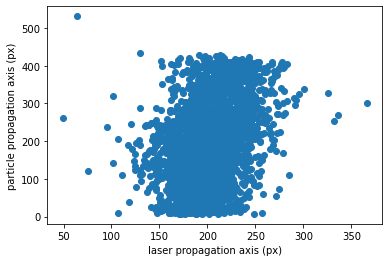

peak intensity of focused particles:  4.1000000000000005
median position: 4.451399774851197
--------------------
5511
5533
5511


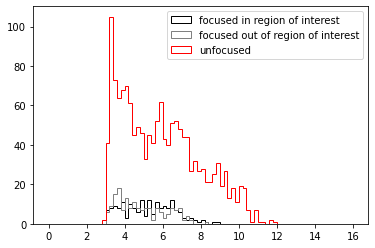

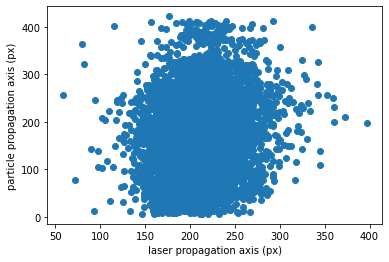

peak intensity of focused particles:  6.4
median position: 5.291874570400608
--------------------
3716
3716
3716


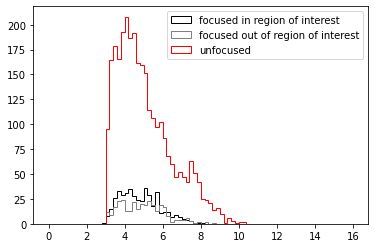

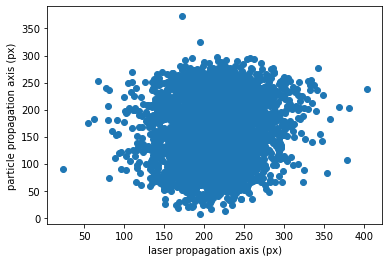

peak intensity of focused particles:  3.4000000000000004
median position: 4.6924428298221
--------------------
1675
1676
1675


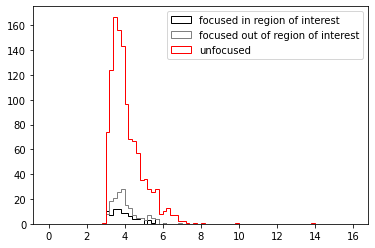

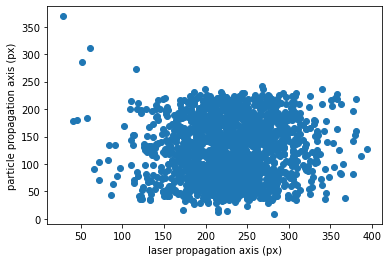

peak intensity of focused particles:  [3.5]
median position: 3.885712962135552
--------------------


In [5]:
#particles = [PS20, PS30, PS40, PS50]
#particles2 = [PS202, PS302, PS402, PS502]

particles = [PS50, PS40, PS30, PS20]
particles2 = [PS502, PS402, PS302, PS202]

intensity_median = []
intensity_mean = []
intensity_std = []
intensity_mad = []

Limit = 0.9

for m in range(len(particles)):

    sample = particles[m]
    sample2 = particles2[m]
    focused = []
    focused_out = []
    unfocused = []
    discard = []
    
    Limitup = 350
    Limitdown = 150
    print(len(sample[4]))
    print(len(sample2[4]))

    minlen = np.min([len(sample[4]),len(sample2[4])])
    print(minlen)
    #for i in range(len(sample[4])-1):
    for i in range(minlen-1):
        if sample[4][i] == sample2[4][i]:
            if sample[1][i] == sample2[1][i]:
                #print(PS50[3][i], PS502[3][i])
                if sample[3][i] >= sample2[3][i] >= Limit*sample[3][i]:
                 #   print("focused")
                    if (sample[2][i]<Limitup)&(sample[2][i]>Limitdown):
                        #if m<3:
                        focused = np.append(focused, sample[3][i])
                        #if m==3:
                        #    if sample[3][i]>8:
                        #        focused = np.append(focused, sample[3][i])
                        #    else:
                        #        print('removed particle')
                    else:
                        focused_out = np.append(focused_out, sample[3][i])

                else:
                   # print("unfocused")
                    unfocused = np.append(unfocused, sample[3][i])
        else:
            try:
                j = np.where(sample2[4] == sample[4][i])[0][0]  #index, where the small circle data == large circle data, 
                                                                # j = 2, i = 0
            except:
                k = 0


            if sample[1][i] == sample2[1][j]:
                if sample[3][i] >= sample2[3][j] >= Limit*sample[3][i]:
                    #print("focused")
                    if (sample[2][i]<Limitup)&(sample[2][i]>Limitdown):
                        if m<3:
                            focused = np.append(focused, sample[3][i])
                        if m==3:
                            if sample[3][i]>6:
                                focused = np.append(focused, sample[3][i])
                            else:
                                discard = np.append(discard, sample[3][i])
                    else:
                        focused_out = np.append(focused_out, sample[3][i])
                else:
                    #print("unfocused")
                    unfocused = np.append(unfocused, sample[3][i])  

        #print("frame number of focused hits:", sample[4][i])
        
    plt.figure()
    plt.hist(focused, bins = 80, range = (0,16), color = "black", label = "focused in region of interest", histtype = 'step')
    plt.hist(focused_out, bins = 80, range = (0,16), color = "gray", label = "focused out of region of interest", histtype = 'step')
    plt.hist(unfocused, bins = 80, range = (0,16), color = "red", label = "unfocused", histtype = 'step')
    plt.legend()
    plt.show()

    plt.figure()
    plt.scatter(sample[1], sample[2])
    plt.ylabel("particle propagation axis (px)")
    plt.xlabel("laser propagation axis (px)")
    plt.show()
    
    #peak position of distribution: 
    histogram = np.histogram(focused, bins = 160, range = (0,16))
    peak = histogram[1][np.argmax(histogram[0])]

    if m == 3:
        peak = histogram[1][np.where(histogram[0] == np.max(histogram[0][25:]))]
    
    print("peak intensity of focused particles: ", peak)
    print("median position:", np.median(focused))    
#    plt.figure()
#    plt.title("position of all particles y-position")
#    plt.scatter(sample[1], sample[2])
#    plt.show()
    
    print("--------------------")   
    if len(focused) == 0:
        focused = np.append(focused, 0)
    intensity_median = np.append(intensity_median, np.median(focused))
    intensity_mean = np.append(intensity_mean, np.mean(focused))
    intensity_std = np.append(intensity_std, np.std(focused))
    intensity_mad = np.append(intensity_mad, scipy.stats.median_abs_deviation(focused))

Using an offset for fitting


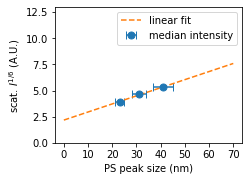

Linear fit summary:
------------------------------------------------------
slope: 0.07737513336974162
offset: 2.1731308982078072
without forcing curve to go through zero
error: [0.01161271 0.37754696]
------------------------------------------------------



In [6]:
#if we dont force it through zero and consider all the PS sizes
UseOffset = True

#diameter = np.array([51, 41, 31, 23]) #peak diameter from DMA histogram
diameter = np.array([41, 31, 23])
intensity_peak = intensity_median[1:]
x_err = np.array([4, 3, 2])

if UseOffset == True:
    print("Using an offset for fitting")
    #popt, pcov = scipy.optimize.curve_fit(linear_b, diameter[:-1], intensity_peak[:-1], p0 = [0.17, 1.56])
    popt, pcov = scipy.optimize.curve_fit(linear_b, diameter, intensity_peak, p0 = [0.17, 1.56])
    a_parts, b_parts = popt
    perr = np.sqrt(np.diag(pcov)) #one standard deviation error
    diams = np.linspace(0, 70)

    plt.figure(figsize = (3.34, 2.5))
    #plt.plot(diameter, intensity_peak, 'o', label = "median intensity")
    plt.errorbar(diameter, intensity_peak, xerr = x_err,  fmt='o', capsize=4, markersize = 7, label = "median intensity")
    plt.plot(diams, a_parts*diams+b_parts, '--', label = "linear fit")
    plt.xlabel("PS peak size (nm)") 
    plt.ylabel("scat. $I^{1/6}$ (A.U.)")
    plt.legend()
    plt.xticks(np.arange(0,71, 10))
    plt.ylim(0, 13)
    plt.show()
    
    print("Linear fit summary:")
    print("------------------------------------------------------")
    print('slope:', a_parts) 
    print('offset:', b_parts)
    print('without forcing curve to go through zero')
    print('error:', perr)
    print("------------------------------------------------------")
    print()

if UseOffset == False:
    print("No offset, forcing fit through zero")
    a_parts, pcov = scipy.optimize.curve_fit(linear, diameter, intensity_peak, p0 = 0.17)
    perr = np.sqrt(np.diag(pcov)) #one standard deviation error
    diams = np.linspace(0, 70)
    
    plt.figure(figsize = (3.34, 2.5))
    plt.plot(diameter, intensity_peak, 'o', label = "median intensity") 
    plt.plot(diams, a_parts*diams, '--', label = "linear fit")
    
    plt.xlabel("PS peak size (nm)") 
    plt.ylabel("scat. $I^{1/6}$ (A.U.)")
    #plt.yscale("log")
    plt.legend()
    plt.xticks(np.arange(0,71, 10))
    plt.ylim(0, 13)
    #plt.savefig("intensity_calibration_BRIO.pdf")
    plt.show()
    
    print("Linear fit summary:")
    print("------------------------------------------------------")
    print('slope:', a_parts) 
    print('with forcing curve to go through zero')
    print('error:', perr)
    print("------------------------------------------------------")
    print()

No offset, forcing fit through zero


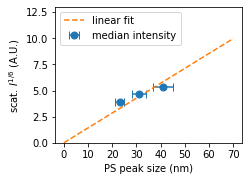

Linear fit summary:
------------------------------------------------------
slope: [0.14247997]
with forcing curve to go through zero
error: [0.0108653]
------------------------------------------------------



In [8]:
#if we dont force it through zero and consider all the PS sizes
UseOffset = False

#diameter = np.array([51, 41, 31, 23]) #peak diameter from DMA histogram
diameter = np.array([41, 31, 23])
intensity_peak = intensity_median[1:]
x_err = np.array([4, 3, 2])

if UseOffset == True:
    print("Using an offset for fitting")
    #popt, pcov = scipy.optimize.curve_fit(linear_b, diameter[:-1], intensity_peak[:-1], p0 = [0.17, 1.56])
    popt, pcov = scipy.optimize.curve_fit(linear_b, diameter, intensity_peak, p0 = [0.17, 1.56])
    a_parts, b_parts = popt
    perr = np.sqrt(np.diag(pcov)) #one standard deviation error
    diams = np.linspace(0, 70)

    plt.figure(figsize = (3.34, 2.5))
    #plt.plot(diameter, intensity_peak, 'o', label = "median intensity")
    plt.errorbar(diameter, intensity_peak, xerr = x_err,  fmt='o', capsize=4, markersize = 7, label = "median intensity")
    plt.plot(diams, a_parts*diams+b_parts, '--', label = "linear fit")
    plt.xlabel("PS peak size (nm)") 
    plt.ylabel("scat. $I^{1/6}$ (A.U.)")
    plt.legend()
    plt.xticks(np.arange(0,71, 10))
    plt.ylim(0, 13)
    plt.show()
    
    print("Linear fit summary:")
    print("------------------------------------------------------")
    print('slope:', a_parts) 
    print('offset:', b_parts)
    print('without forcing curve to go through zero')
    print('error:', perr)
    print("------------------------------------------------------")
    print()

if UseOffset == False:
    print("No offset, forcing fit through zero")
    a_parts, pcov = scipy.optimize.curve_fit(linear, diameter, intensity_peak, p0 = 0.17)
    perr = np.sqrt(np.diag(pcov)) #one standard deviation error
    diams = np.linspace(0, 70)
    
    plt.figure(figsize = (3.34, 2.5))
    #plt.plot(diameter, intensity_peak, 'o', label = "median intensity") 
    plt.errorbar(diameter, intensity_peak, xerr = x_err,  fmt='o', capsize=4, markersize = 7, label = "median intensity")
    plt.plot(diams, a_parts*diams, '--', label = "linear fit")
    
    plt.xlabel("PS peak size (nm)") 
    plt.ylabel("scat. $I^{1/6}$ (A.U.)")
    #plt.yscale("log")
    plt.legend()
    plt.xticks(np.arange(0,71, 10))
    plt.ylim(0, 13)
    #plt.savefig("intensity_calibration_BRIO.pdf")
    plt.show()
    
    print("Linear fit summary:")
    print("------------------------------------------------------")
    print('slope:', a_parts) 
    print('with forcing curve to go through zero')
    print('error:', perr)
    print("------------------------------------------------------")
    print()